In [2]:
from dotenv import load_dotenv
from groq import Groq

load_dotenv()

client = Groq()

models = client.models.list()

for model in models.data:
    print(model.id)


allam-2-7b
openai/gpt-oss-20b
openai/gpt-oss-120b
groq/compound
meta-llama/llama-prompt-guard-2-86m
groq/compound-mini
meta-llama/llama-prompt-guard-2-22m
whisper-large-v3
canopylabs/orpheus-arabic-saudi
whisper-large-v3-turbo
openai/gpt-oss-safeguard-20b
canopylabs/orpheus-v1-english
qwen/qwen3.8-27b


In [3]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

response = llm.invoke("Write a short sentence about self attention.")
print(response.content)


Self‑attention lets a model weigh each token against all others in the same sequence, highlighting the most relevant parts of its own input.


In [4]:
from __future__ import annotations

import operator
import os
import re
from datetime import date, datetime, timedelta
from pathlib import Path
from typing import TypedDict, List, Optional, Literal, Annotated

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()


In [5]:
# -----------------------------
# 1) Schemas
# -----------------------------
class Task(BaseModel):
    id: int
    title: str
    section_type: str = Field("section", description="Section type, e.g. introduction, deep_dive, tutorial, conclusion.")

    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=6,
        description="3–6 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(..., description="Target word count for this section (120–550).")

    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False


class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str

    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"

    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]


class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # prefer ISO "YYYY-MM-DD"
    snippet: Optional[str] = None
    source: Optional[str] = None


class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    reason: str
    queries: List[str] = Field(default_factory=list)
    max_results_per_query: int = Field(5, description="How many results to fetch per query (3–8).")


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)


In [7]:
class State(TypedDict):
    topic: str

    # routing / research
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]

    # recency control
    as_of: str           # ISO date, e.g. "2026-01-29"
    recency_days: int    # 7 for weekly news, 30 for hybrid, etc.

    # workers
    sections: Annotated[List[tuple[int, str]], operator.add]  # (task_id, section_md)
    final: str


In [9]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)


In [8]:
# -----------------------------
# 3) Router (decide upfront)
# -----------------------------
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3–10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- For open_book weekly roundup, include queries that reflect the last 7 days constraint.
"""

def router_node(state: State) -> dict:
    topic = state["topic"]
    as_of = state.get("as_of") or date.today().isoformat()
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}\nAs-of date: {as_of}"),
        ]
    )

    # Set default recency window based on mode
    if decision.mode == "open_book":
        recency_days = 7
    elif decision.mode == "hybrid":
        recency_days = 45
    else:
        recency_days = 3650

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
        "recency_days": recency_days,
        "as_of": as_of,
    }

def route_next(state: State) -> str:
    return "research" if state.get("needs_research") else "orchestrator"


In [ ]:
# -----------------------------
# 4) Research (Tavily)
# -----------------------------
def _tavily_search(query: str, max_results: int = 5) -> List[dict]:
    """
    Uses TavilySearchResults if installed and TAVILY_API_KEY is set.
    Returns list of dict with common fields. Note: published date is often missing.
    """
    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query": query})

    normalized: List[dict] = []
    for r in results or []:
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )
    return normalized


def _iso_to_date(s: Optional[str]) -> Optional[date]:
    if not s:
        return None
    try:
        return date.fromisoformat(s[:10])
    except Exception:
        return None


RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- Extract/normalize published_at as ISO (YYYY-MM-DD) if you can infer it from title/snippet.
  If you can't infer a date reliably, set published_at=null (do NOT guess).
- Keep snippets short.
- Deduplicate by URL.
"""

def research_node(state: State) -> dict:
    queries = (state.get("queries", []) or [])[:10]
    max_results = 6

    raw_results: List[dict] = []
    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)
    as_of = state.get("as_of") or date.today().isoformat()
    recency_days = state.get("recency_days", 30)

    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(
                content=(
                    f"As-of date: {as_of}\n"
                    f"Recency days: {recency_days}\n\n"
                    f"Raw results:\n{raw_results}"
                )
            ),
        ]
    )

    # Deduplicate by URL
    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e
    evidence = list(dedup.values())

    # HARD RECENCY FILTER for open_book weekly roundup:
    # keep only items with a parseable ISO date and within the window.
    mode = state.get("mode", "closed_book")
    if mode == "open_book":
        as_of_date = date.fromisoformat(as_of)
        cutoff = as_of_date - timedelta(days=int(recency_days))
        fresh: List[EvidenceItem] = []
        for e in evidence:
            d = _iso_to_date(e.published_at)
            if d and d >= cutoff:
                fresh.append(e)
        evidence = fresh

    return {"evidence": evidence}


In [ ]:
# -----------------------------
# 5) Orchestrator (Plan)
# -----------------------------
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 3–6 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3–5 bullets that are concrete, specific, and non-overlapping
  3) target word count (120–550)

Formatting rule:
- Do not use raw LaTeX backslashes or unsupported JSON escape sequences in equations/text. Write formulas in plain text (e.g., y = b0 + b1*x1 + e).

Flexibility:
- Do NOT use a fixed taxonomy unless it naturally fits.
- You may tag tasks (tags field), but tags are flexible.

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book (weekly news roundup):
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections (no scraping/RSS/how to fetch news) unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient fresh sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""

def orchestrator_node(state: State) -> dict:
    planner = llm.with_structured_output(Plan)
    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")
    as_of = state.get("as_of") or date.today().isoformat()
    recency_days = state.get("recency_days", 3650)

    # Force blog_kind for open_book
    forced_kind = "news_roundup" if mode == "open_book" else None

    plan = planner.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n"
                    f"As-of: {as_of} (recency_days={recency_days})\n"
                    f"{'Force blog_kind=news_roundup' if forced_kind else ''}\n\n"
                    f"Evidence (ONLY use for fresh claims; may be empty):\n"
                    f"{[e.model_dump() if hasattr(e, 'model_dump') else e for e in evidence][:16]}\n\n"
                    f"Instruction: If mode=open_book, your plan must NOT drift into a tutorial."
                )
            ),
        ]
    )

    # Ensure open_book forces the kind even if model forgets
    if forced_kind:
        plan.blog_kind = "news_roundup"

    return {"plan": plan}

# Backwards compatibility alias
orchestrator = orchestrator_node


In [27]:
# -----------------------------
# 6) Fanout
# -----------------------------
def fanout(state: State):
    assert state["plan"] is not None
    return [
        Send(
            "worker",
            {
                "task": task,
                "topic": state["topic"],
                "mode": state.get("mode", "closed_book"),
                "as_of": state.get("as_of", ""),
                "recency_days": state.get("recency_days", 30),
                "plan": state["plan"],
                "evidence": state.get("evidence", []),
            },
        )
        for task in state["plan"].tasks
    ]


In [11]:
# -----------------------------
# 7) Worker
# -----------------------------
def worker(payload: dict) -> dict:
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    # Support both Pydantic models and dicts
    if isinstance(task, dict):
        task_id = task.get("id", 0)
        title = task.get("title", "")
        goal = task.get("goal", "")
        bullets = task.get("bullets", [])
        target_words = task.get("target_words", 300)
        section_type = task.get("section_type", "section")
    else:
        task_id = getattr(task, "id", 0)
        title = getattr(task, "title", "")
        goal = getattr(task, "goal", "")
        bullets = getattr(task, "bullets", [])
        target_words = getattr(task, "target_words", 300)
        section_type = getattr(task, "section_type", "section")

    if isinstance(plan, dict):
        blog_title = plan.get("blog_title", "")
        audience = plan.get("audience", "developers")
        tone = plan.get("tone", "technical")
    else:
        blog_title = getattr(plan, "blog_title", "")
        audience = getattr(plan, "audience", "developers")
        tone = getattr(plan, "tone", "technical")

    bullets_text = "\n- " + "\n- ".join(bullets)

    section_md = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
                    "Hard constraints:\n"
                    "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
                    "- Stay close to the Target words (±15%).\n"
                    "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
                    "Technical quality bar:\n"
                    "- Be precise and implementation-oriented (developers should be able to apply it).\n"
                    "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
                    "- When relevant, include code snippets, examples, or tables.\n"
                    "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
                    "- Call out edge cases / failure modes.\n\n"
                    "Markdown style:\n"
                    "- Start with a '## <Section Title>' heading.\n"
                    "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
                    "- Avoid fluff. Avoid marketing language.\n"
                )
            ),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Audience: {audience}\n"
                    f"Tone: {tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {title}\n"
                    f"Section type: {section_type}\n"
                    f"Goal: {goal}\n"
                    f"Target words: {target_words}\n"
                    f"Bullets:{bullets_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [(task_id, section_md)]}


In [29]:
# -----------------------------
# 8) Reducer
# -----------------------------
import re
from pathlib import Path

def reducer(state: State) -> dict:
    plan = state["plan"]
    title = plan.blog_title if hasattr(plan, "blog_title") else plan["blog_title"]

    sections = state.get("sections", [])
    # Sort sections by task id if stored as tuples to guarantee correct order
    if sections and isinstance(sections[0], (tuple, list)):
        sorted_sections = [s[1] for s in sorted(sections, key=lambda x: x[0])]
    else:
        sorted_sections = sections

    body = "\n\n".join(sorted_sections).strip()
    final_md = f"# {title}\n\n{body}\n"

    output_dir = Path("outputs")
    output_dir.mkdir(exist_ok=True)

    # Safe filename
    filename = re.sub(r'[<>:"/\\|?*]', '', title)
    filename = filename.lower().replace(" ", "_") + ".md"

    output_path = output_dir / filename
    output_path.write_text(final_md, encoding="utf-8")

    print("[Saved]:", output_path.resolve())

    return {"final": final_md}


In [30]:
# -----------------------------
# 9) Build Graph
# -----------------------------
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker)
g.add_node("reducer", reducer)


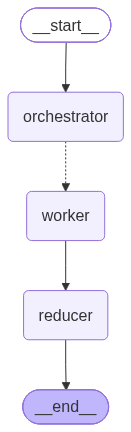

In [31]:
g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, ["research", "orchestrator"])
g.add_edge("research", "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app


In [32]:
out = app.invoke({"topic": "Write a blog on machine learning", "sections": []})
print(out["final"])


✅ Saved: C:\Users\hp\Desktop\Blog Agent\outputs\from_model_to_production_a_practical_guide_to_deploying_machine_learning_services.md
# From Model to Production: A Practical Guide to Deploying Machine Learning Services

## Introduction: Why Productionizing ML Matters

Low‑latency inference is critical for many real‑world ML applications. Typical use cases include:

- Recommendation engines that personalize content in milliseconds.  
- Fraud detection systems that flag suspicious transactions on the fly.  
- Real‑time image or speech recognition in consumer devices.  
- Dynamic pricing engines that adjust rates instantly.  
- Autonomous vehicle perception that must react within sub‑seconds.  

When moving from research notebooks to a live service, three obstacles dominate:

1. **Data drift** – the distribution of incoming data changes, degrading accuracy.  
2. **Resource constraints** – limited CPU, GPU, or memory budgets force model compression or batching.  
3. **Model versioning** – k

In [34]:
from langchain_core.messages.tool import tool_call
from langchain_community.tools.tavily_search import TavilySearchResults
tool = TavilySearchResults()
result = tool.invoke({"query": "chatgpt release model from 2022 to 2026"})
result


C:\Users\hp\AppData\Local\Temp\ipykernel_3736\3347727655.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool =TavilySearchResults()


[{'title': 'OpenAI GPT & ChatGPT Timeline (2022 → Feb 2026)',
  'url': 'https://www.linkedin.com/pulse/openai-gpt-chatgpt-timeline-2022-feb-2026-sanjana-r-pmp-cspo--pxfoc',
  'content': "This timeline documents the evolution of OpenAI's GPT models and ChatGPT product based on public announcements, release notes, and ecosystem",
  'score': 0.78413767},
 {'title': 'ChatGPT Version History List, Changelog & Latest Releases - Objects',
  'url': 'https://objects.ws/blog/chatgpt-version-history',
  'content': 'OpenAI’s GPT models have powered both ChatGPT’s current and previous versions, which efficiently use massive amounts of text data to respond to and comprehend user prompts. As you know, ChatGPT started its journey in 2022, when its first version was launched.\n\n## OpenAI’s GPT-5.6 Released With a Limited Preview\n\nOpenAI has launched GPT-5.6, its next-generation model, on June 27, 2026. GPT-5.6 is a restricted release, which means it offers a limited preview.\n\n### GPT-5.6 Has Three

In [37]:
for r in result:
    file = r['content']
file


'Buy this spot\n\nReach developers, founders and AI enthusiasts who follow every new model release.\n\nAudience\n\nWhat you get\n\nMENU\n\n# OpenAI\n\n44 releases · Nov 2022 – Sep 2026\n\nCreators of ChatGPT and the GPT series of models. Pioneered large-scale language model research. AI Release Tracker has logged 44 OpenAI models, from GPT-3.5 (Nov 30 2022) through GPT-6 Astra (Sep 3 2026). Every release below links to a dedicated page with benchmarks, parameters, and context window.'